# Лабораторная 3. Полиномиальная регрессия. Регуляризация. Кросс-валидация

**Задание 3.** Реализовать программно восстановление функциональной зависимости
методом наименьших квадратов с помощью полиномиальной регрессии. Для этого
использовать значения параметра $M \in \{0, 1, \ldots, 15\}$; генерировать
выборку двумя способами, моделируя ошибку измерения как равномерно и как
нормально распределённую случайную величину; значения $x$ генерировать из
заданного интервала случайно в соответствии с равномерным распределением; в
качестве распознаваемых зависимостей использовать
$y = \cos x$, $y = 5x^3 + x^2 + 5$, $y = x \sin x$ на $x \in [0, 2\pi]$.

**Задание 5.** При тех же условиях реализовать регуляризацию и показать, что
переобучение может быть устранено при некоторых значениях $M$ и $\lambda$; найти
эти значения.

**Задание 6.** Реализовать кросс-валидацию для полиномиальной регрессии с
регуляризацией. Определить наилучшую пару $(M, \lambda)$.

## 1. Теория

### Данные

Выборка $\{(x_k, y_k)\}_{k=1}^{N}$ генерируется:
$y_k = f(x_k) + \varepsilon_k$, значения $x_k$ равномерны на $[0, 2\pi]$,
восстанавливаемые зависимости $f$ это $\cos x$, $5x^3 + x^2 + 5$, $x \sin x$.
Ошибка измерения моделируется двумя способами, равномерным
$\varepsilon \sim \mathrm{U}[-\varepsilon_0, \varepsilon_0]$ и нормальным
$\varepsilon \sim \mathrm{N}(0, \sigma^2)$ с $\sigma = \varepsilon_0 / \sqrt3$,
чтобы дисперсии совпадали. Амплитуда $\varepsilon_0$ берётся равной $15\%$
размаха функции на интервале. Обучающая выборка 25 точек, тестовая 500.

### Метод наименьших квадратов

Приближение ищется в виде многочлена

$$\tilde f(x, w) = \sum_{j=0}^{M} w_j x^j,$$

минимизирующего сумму квадратов отклонений

$$E(w) = \frac12 \sum_{k=1}^{N}\bigl(y_k - \tilde f(x_k, w)\bigr)^2 .$$

Приравнивание нулю производных по $w_i$ даёт систему нормальных уравнений

$$\sum_{j=0}^{M} a_{ij} w_j = b_i,
\qquad a_{ij} = \sum_{k} x_k^{\,i+j},
\qquad b_i = \sum_{k} x_k^{\,i} y_k,$$

то есть $Aw = b$, где $A = V^{\top}V$, $b = V^{\top}y$ и $V = (x_k^{\,j})$ это
матрица Вандермонда. Система однозначно разрешима, когда число различных узлов
не меньше $M + 1$.

### Регуляризация

К функции ошибки добавляется штраф за величину коэффициентов, свободный член
$w_0$ в него не входит:

$$E_\lambda(w) = \frac12\sum_{k=1}^{N}\bigl(y_k - \tilde f(x_k, w)\bigr)^2
             + \frac{\lambda}{2}\sum_{j=1}^{M} w_j^2 .$$

Условие минимума даёт

$$(A + \lambda I_0)\,w = b, \qquad I_0 = \mathrm{diag}(0, 1, \ldots, 1),$$

то есть $\lambda$ прибавляется ко всем диагональным элементам $A$, кроме первого.

### Кросс-валидация

Выборка разбивается на $F$ частей; модель $F$ раз обучается на $F - 1$ частях и
оценивается на оставшейся, ошибки усредняются.

### Масштабирование аргумента

Базис строится не по $x$, а по $t = 2(x - a)/(b - a) - 1 \in [-1, 1]$. Многочлен
степени $M$ от $t$ это тот же многочлен степени $M$ от $x$, но элементы матрицы
$A$ перестают различаться на десятки порядков. Коэффициенты $w$ и штраф
относятся к многочлену от $t$.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| степень $M$ | 0, 1, ..., 15 |
| $\lambda$ | 0 и 25 значений от $10^{-10}$ до $10^{2}$, равномерно по $\log_{10}\lambda$ |
| ошибка измерения | равномерная, нормальная |
| число частей $F$ | 5 |

### Мера ошибки

$$\mathrm{RMSE} = \sqrt{\frac1n \sum_{k=1}^{n}\bigl(\tilde f(x_k, w) - y_k\bigr)^2}.$$

## 2. Генерация выборки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

A_INT, B_INT = 0.0, 2 * np.pi

FUNCS = {
    'cos x': lambda x: np.cos(x),
    '5x^3 + x^2 + 5': lambda x: 5 * x ** 3 + x ** 2 + 5,
    'x sin x': lambda x: x * np.sin(x),
}

In [2]:
def make_sample(f, n, noise, eps, rng):
    """x равномерно на [0, 2pi]; ошибка равномерная либо нормальная."""
    x = rng.uniform(A_INT, B_INT, n)
    clean = f(x)
    if noise == 'равномерный':
        e = rng.uniform(-eps, eps, n)
    elif noise == 'нормальный':
        e = rng.normal(0.0, eps / np.sqrt(3), n)
    else:
        raise ValueError(noise)
    return x, clean + e


NOISE_SCALE = {}
for name, f in FUNCS.items():
    grid = np.linspace(A_INT, B_INT, 1000)
    NOISE_SCALE[name] = 0.15 * (f(grid).max() - f(grid).min())
    print(f'{name:16s} размах {f(grid).max() - f(grid).min():9.3f}  '
          f'амплитуда шума {NOISE_SCALE[name]:8.3f}')

cos x            размах     2.000  амплитуда шума    0.300
5x^3 + x^2 + 5   размах  1279.729  амплитуда шума  191.959
x sin x          размах     6.634  амплитуда шума    0.995


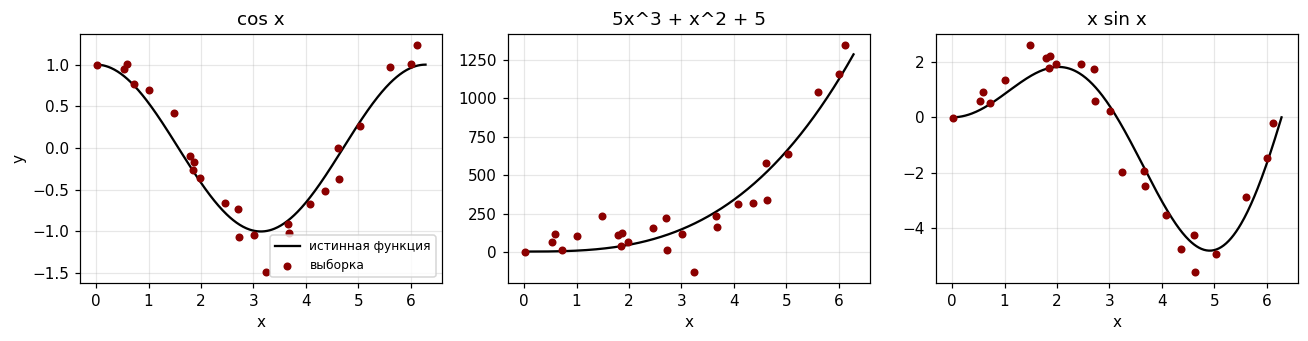

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(A_INT, B_INT, 400)
for ax, (name, f) in zip(axes, FUNCS.items()):
    x, yv = make_sample(f, 25, 'нормальный', NOISE_SCALE[name], np.random.default_rng(3))
    ax.plot(grid, f(grid), color='black', label='истинная функция')
    ax.scatter(x, yv, color='darkred', s=18, zorder=3, label='выборка')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Реализация полиномиальной регрессии

In [4]:
def scale(x):
    """Перенос отрезка [0, 2pi] в [-1, 1]."""
    return 2.0 * (x - A_INT) / (B_INT - A_INT) - 1.0


def normal_system(t, y, M):
    """Система Aw = b по формулам a_ij = сумма t^(i+j), b_i = сумма t^i * y."""
    A = np.empty((M + 1, M + 1))
    b = np.empty(M + 1)
    for i in range(M + 1):
        b[i] = (t ** i * y).sum()
        for j in range(M + 1):
            A[i, j] = (t ** (i + j)).sum()
    return A, b


def fit(x, y, M, lam=0.0):
    """Коэффициенты многочлена степени M методом наименьших квадратов."""
    A, b = normal_system(scale(x), y, M)
    for j in range(1, M + 1):
        A[j, j] += lam  # регуляризация прибавляет lambda к диагонали, кроме w_0
    return np.linalg.solve(A, b)


def predict(w, x):
    """Значение многочлена с коэффициентами w в точках x."""
    t = scale(x)
    return sum(w[j] * t ** j for j in range(len(w)))


def rmse(w, x, y):
    return float(np.sqrt(np.mean((predict(w, x) - y) ** 2)))

In [5]:
x_chk, y_chk = make_sample(FUNCS['x sin x'], 40, 'нормальный', 1.0, np.random.default_rng(11))
w_mine = fit(x_chk, y_chk, 5)
# матрица плана: столбец j это t^j, по ней lstsq решает ту же задачу
V = np.column_stack([scale(x_chk) ** j for j in range(6)])
w_ref = np.linalg.lstsq(V, y_chk, rcond=None)[0]
print(f'расхождение с lstsq: {np.abs(w_mine - w_ref).max():.2e}')

print('\nчисло обусловленности матрицы A:')
print(f'{"M":>3} {"без масштабирования":>22} {"с масштабированием":>22}')
for M in (3, 7, 11, 15):
    A_raw = normal_system(x_chk, y_chk, M)[0]
    A_scaled = normal_system(scale(x_chk), y_chk, M)[0]
    print(f'{M:3d} {np.linalg.cond(A_raw):22.3e} {np.linalg.cond(A_scaled):22.3e}')

расхождение с lstsq: 5.12e-13

число обусловленности матрицы A:
  M    без масштабирования     с масштабированием
  3              6.045e+05              9.602e+01
  7              2.511e+14              7.958e+04
 11              4.904e+21              1.366e+08
 15              3.082e+28              3.661e+11


## 4. Задание 3: перебор степени многочлена

In [6]:
N_TRAIN, N_TEST = 25, 500
MS = list(range(16))

rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        for M in MS:
            w = fit(x_tr, y_tr, M)
            rows.append(dict(func=name, noise=noise, M=M, lam=0.0,
                             train=rmse(w, x_tr, y_tr), test=rmse(w, x_te, y_te),
                             wmax=float(np.abs(w).max())))

plain = pd.DataFrame(rows)
sub = plain[(plain.func == 'x sin x') & (plain.noise == 'нормальный')]
print('x sin x, нормальный шум:')
print(sub[['M', 'train', 'test', 'wmax']].round(3).to_string(index=False))

x sin x, нормальный шум:
 M  train   test      wmax
 0  2.523  2.298     0.890
 1  1.787  1.622     3.370
 2  1.786  1.637     3.401
 3  0.885  0.913     9.562
 4  0.463  0.676     9.386
 5  0.408  0.713    16.223
 6  0.407  0.737    16.781
 7  0.406  0.780    13.495
 8  0.405  0.860    17.088
 9  0.403  1.083    48.778
10  0.403  1.160    64.496
11  0.384  6.142  2216.448
12  0.383  9.182  3076.506
13  0.378 30.149  9178.025
14  0.362 48.050 55365.924
15  0.361  5.126 55366.072


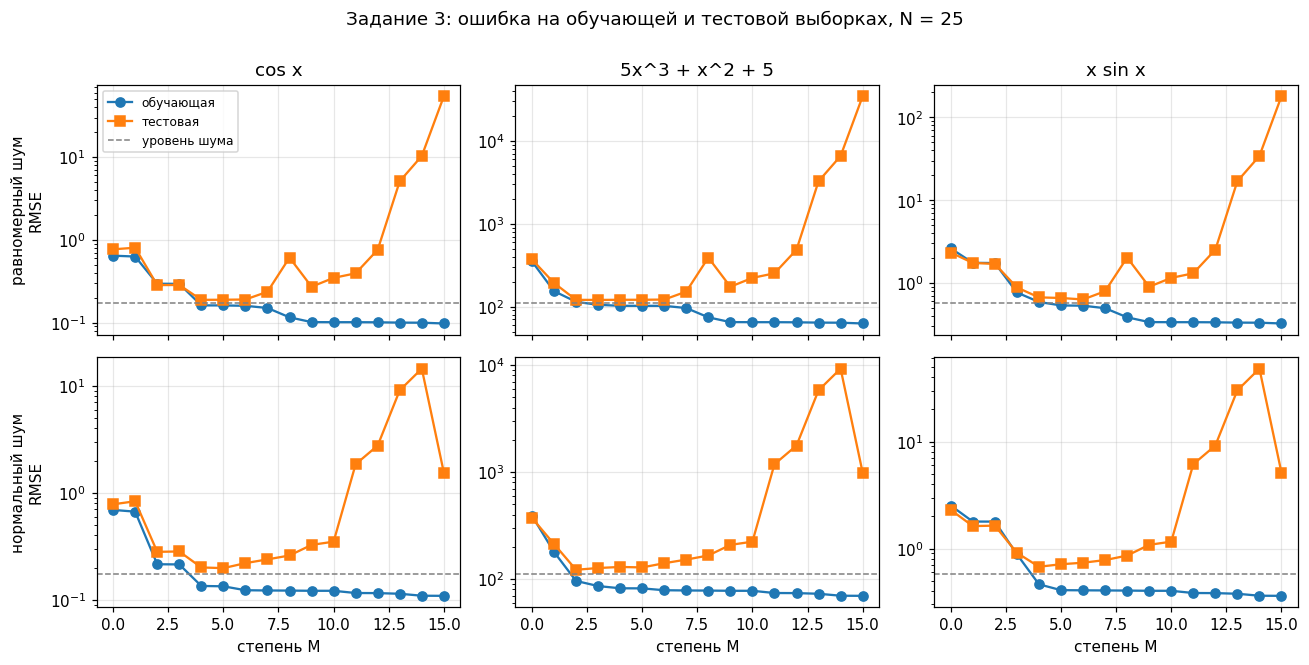

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for col, name in enumerate(FUNCS):
    for row, noise in enumerate(('равномерный', 'нормальный')):
        ax = axes[row, col]
        s = plain[(plain.func == name) & (plain.noise == noise)]
        ax.semilogy(s.M, s.train, marker='o', label='обучающая')
        ax.semilogy(s.M, s.test, marker='s', label='тестовая')
        ax.axhline(NOISE_SCALE[name] / np.sqrt(3), color='gray', ls='--', lw=1,
                   label='уровень шума')
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(name)
        if row == 1:
            ax.set_xlabel('степень M')
        if col == 0:
            ax.set_ylabel(f'{noise} шум\nRMSE')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Задание 3: ошибка на обучающей и тестовой выборках, N = 25', y=1.0)
plt.tight_layout()
plt.show()

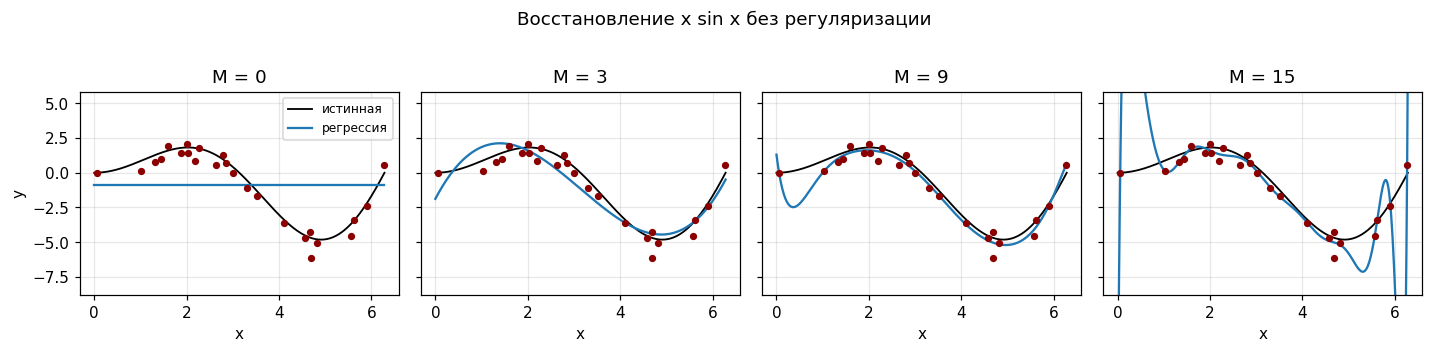

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.1), sharey=True)
name = 'x sin x'
f = FUNCS[name]
rng = np.random.default_rng(20260905)
x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE[name], rng)
grid = np.linspace(A_INT, B_INT, 400)
for ax, M in zip(axes, [0, 3, 9, 15]):
    w = fit(x_tr, y_tr, M)
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_ylim(f(grid).min() - 4, f(grid).max() + 4)
    ax.set_title(f'M = {M}')
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
fig.suptitle('Восстановление x sin x без регуляризации', y=1.02)
plt.tight_layout()
plt.show()

## 5. Задание 5: регуляризация

In [9]:
LAMBDAS = np.concatenate([[0.0], np.logspace(-10, 2, 25)])

rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        for M in MS:
            for lam in LAMBDAS:
                w = fit(x_tr, y_tr, M, lam)
                rows.append(dict(func=name, noise=noise, M=M, lam=lam,
                                 train=rmse(w, x_tr, y_tr), test=rmse(w, x_te, y_te),
                                 wmax=float(np.abs(w).max())))

reg = pd.DataFrame(rows)

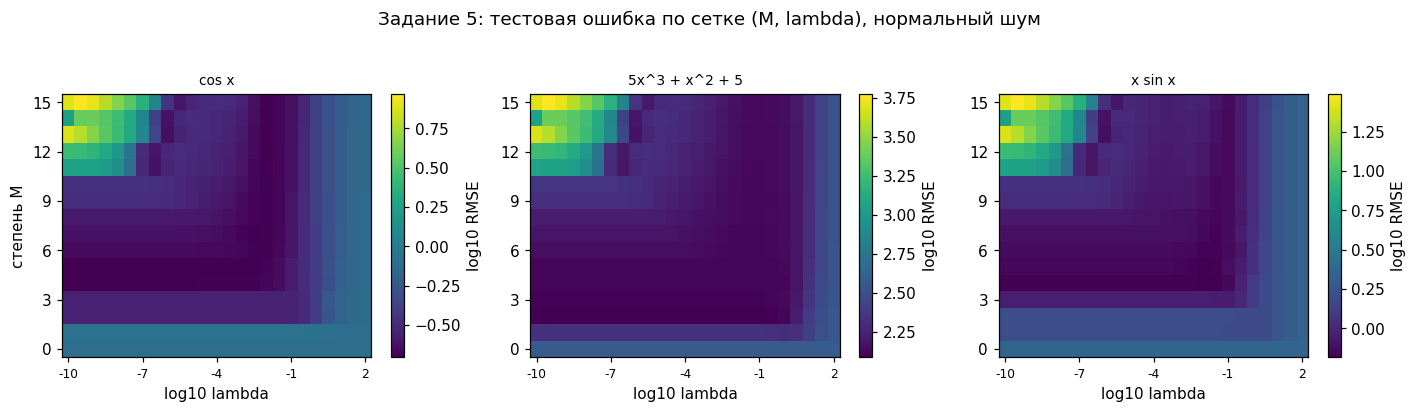

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, name in zip(axes, FUNCS):
    s = reg[(reg.func == name) & (reg.noise == 'нормальный') & (reg.lam > 0)]
    piv = s.pivot_table(index='M', columns='lam', values='test')
    im = ax.imshow(np.log10(piv.values), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('log10 lambda')
    ax.set_xticks(range(0, len(piv.columns), 6))
    ax.set_xticklabels([f'{np.log10(v):.0f}' for v in piv.columns[::6]], fontsize=8)
    ax.set_yticks(range(0, 16, 3))
    plt.colorbar(im, ax=ax, label='log10 RMSE')
axes[0].set_ylabel('степень M')
fig.suptitle('Задание 5: тестовая ошибка по сетке (M, lambda), нормальный шум', y=1.03)
plt.tight_layout()
plt.show()

In [11]:
def best_rows(df, column):
    """Строка с минимальным значением column для каждой пары функция, шум."""
    rows = [g.loc[g[column].idxmin()] for _, g in df.groupby(['func', 'noise'])]
    return pd.DataFrame(rows)


best_plain = best_rows(plain, 'test')
best_reg = best_rows(reg[reg.lam > 0], 'test')
print('лучшее без регуляризации:')
print(best_plain[['func', 'noise', 'M', 'train', 'test', 'wmax']].round(4).to_string(index=False))
print('\nлучшее с регуляризацией:')
print(best_reg[['func', 'noise', 'M', 'lam', 'train', 'test', 'wmax']].to_string(
    index=False, float_format='{:.4f}'.format, formatters={'lam': '{:.0e}'.format}))

лучшее без регуляризации:
          func       noise  M    train     test     wmax
5x^3 + x^2 + 5  нормальный  2  96.1150 122.1611 576.3932
5x^3 + x^2 + 5 равномерный  3 105.1019 120.4017 385.5541
         cos x  нормальный  5   0.1338   0.1978   4.1512
         cos x равномерный  4   0.1616   0.1886   4.7493
       x sin x  нормальный  4   0.4634   0.6758   9.3856
       x sin x равномерный  6   0.5314   0.6320  16.1502

лучшее с регуляризацией:
          func       noise  M   lam    train     test     wmax
5x^3 + x^2 + 5  нормальный  2 1e-01  96.4189 121.7817 571.6137
5x^3 + x^2 + 5 равномерный  8 3e-03 101.1921 120.3295 609.0606
         cos x  нормальный  5 1e-10   0.1338   0.1978   4.1512
         cos x равномерный  4 3e-03   0.1620   0.1880   4.6182
       x sin x  нормальный  4 3e-02   0.5132   0.6569   8.7725
       x sin x равномерный  8 1e-03   0.5219   0.6210  16.1891


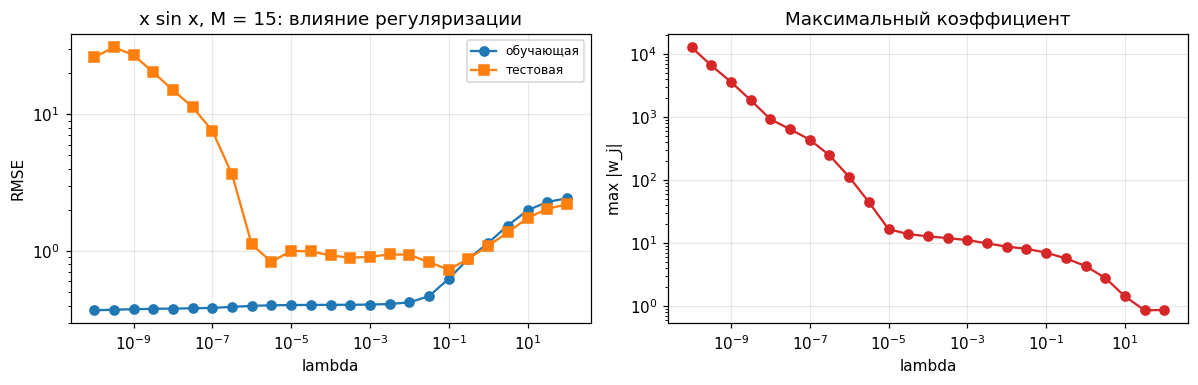

In [12]:
name = 'x sin x'
s15 = reg[(reg.func == name) & (reg.noise == 'нормальный') & (reg.M == 15) & (reg.lam > 0)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].loglog(s15.lam, s15.train, marker='o', label='обучающая')
axes[0].loglog(s15.lam, s15.test, marker='s', label='тестовая')
axes[0].set_xlabel('lambda'); axes[0].set_ylabel('RMSE')
axes[0].set_title(f'{name}, M = 15: влияние регуляризации')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].loglog(s15.lam, s15.wmax, marker='o', color='tab:red')
axes[1].set_xlabel('lambda'); axes[1].set_ylabel('max |w_j|')
axes[1].set_title('Максимальный коэффициент')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
name = 'x sin x'
f = FUNCS[name]
rng = np.random.default_rng(20260905)
x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE[name], rng)
x_te, y_te = make_sample(f, N_TEST, 'нормальный', NOISE_SCALE[name], rng)

print(f'{name}, M = 15:')
print(f'{"lambda":>10} {"RMSE обуч":>10} {"RMSE тест":>10} {"max |w|":>12}')
for lam in [0.0, 1e-6, 1e-4, 1e-1, 1e1]:
    w = fit(x_tr, y_tr, 15, lam)
    print(f'{lam:10.0e} {rmse(w, x_tr, y_tr):10.3f} {rmse(w, x_te, y_te):10.3f} '
          f'{np.abs(w).max():12.1f}')

s15 = reg[(reg.func == name) & (reg.noise == 'нормальный') & (reg.M == 15) & (reg.lam > 0)]
best15 = s15.loc[s15.test.idxmin()]
print(f'\nминимум тестовой ошибки при M = 15: lambda = {best15.lam:.2e}, '
      f'RMSE = {best15.test:.3f}')

x sin x, M = 15:
    lambda  RMSE обуч  RMSE тест      max |w|
     0e+00      0.361      5.126      55366.1
     1e-06      0.398      1.118        112.4
     1e-04      0.405      0.931         12.9
     1e-01      0.628      0.733          7.1
     1e+01      1.986      1.744          1.4

минимум тестовой ошибки при M = 15: lambda = 1.00e-01, RMSE = 0.733


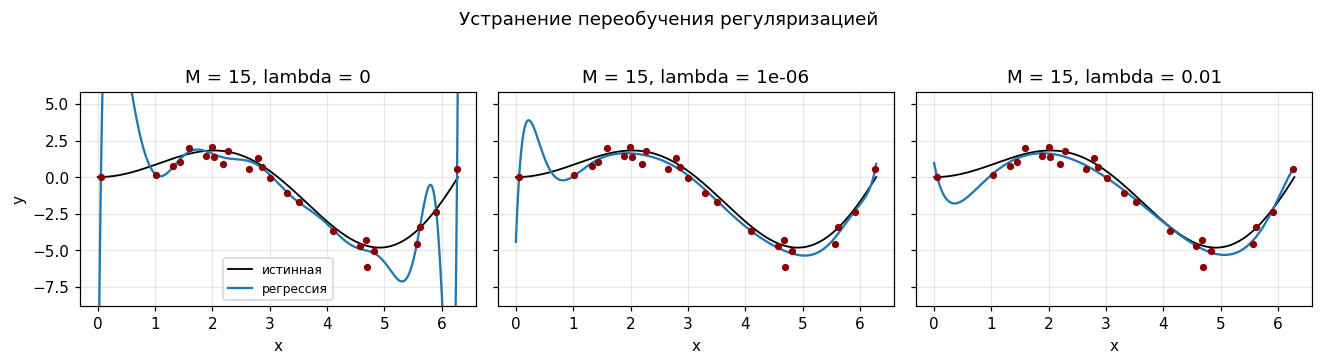

In [14]:
f = FUNCS['x sin x']
rng = np.random.default_rng(20260905)
x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE['x sin x'], rng)
grid = np.linspace(A_INT, B_INT, 400)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, lam in zip(axes, [0.0, 1e-6, 1e-2]):
    w = fit(x_tr, y_tr, 15, lam)
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_ylim(f(grid).min() - 4, f(grid).max() + 4)
    ax.set_title(f'M = 15, lambda = {lam:g}')
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
fig.suptitle('Устранение переобучения регуляризацией', y=1.02)
plt.tight_layout()
plt.show()

## 6. Задание 6: кросс-валидация

In [15]:
def cv_error(x, y, M, lam, folds, rng):
    """Средний RMSE по отложенным частям выборки."""
    idx = np.arange(len(x))
    rng.shuffle(idx)
    parts = np.array_split(idx, folds)  # перемешанные индексы делятся на folds частей
    errs = []
    for i in range(folds):
        val = parts[i]
        tr = np.concatenate([parts[j] for j in range(folds) if j != i])
        w = fit(x[tr], y[tr], M, lam)
        errs.append(rmse(w, x[val], y[val]))
    return float(np.mean(errs))

In [16]:
rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        for M in MS:
            for lam in LAMBDAS:
                cv = cv_error(x_tr, y_tr, M, lam, folds=5,
                              rng=np.random.default_rng(1))
                w = fit(x_tr, y_tr, M, lam)
                rows.append(dict(func=name, noise=noise, M=M, lam=lam,
                                 cv=cv, test=rmse(w, x_te, y_te)))

cvres = pd.DataFrame(rows)
cvres.to_csv('results.csv', index=False)

In [17]:
best_cv = best_rows(cvres, 'cv')
best_true = best_rows(cvres, 'test')
comp = best_cv[['func', 'noise', 'M', 'lam', 'cv', 'test']].merge(
    best_true[['func', 'noise', 'M', 'lam', 'test']],
    on=['func', 'noise'], suffixes=(' по CV', ' по тесту'))
print(comp.to_string(index=False, float_format='{:.4f}'.format,
                     formatters={'lam по CV': '{:.0e}'.format, 'lam по тесту': '{:.0e}'.format}))

          func       noise  M по CV lam по CV       cv  test по CV  M по тесту lam по тесту  test по тесту
5x^3 + x^2 + 5  нормальный        4     1e-01 102.4635    129.1089           2        1e-01       121.7817
5x^3 + x^2 + 5 равномерный        3     3e-01 129.8319    125.6655           8        3e-03       120.3295
         cos x  нормальный        4     1e-02   0.1805      0.2074           5        0e+00         0.1978
         cos x равномерный        5     3e-04   0.2093      0.1889           4        3e-03         0.1880
       x sin x  нормальный        5     0e+00   0.6830      0.7134           4        3e-02         0.6569
       x sin x равномерный        4     3e-02   0.7548      0.6906           8        1e-03         0.6210


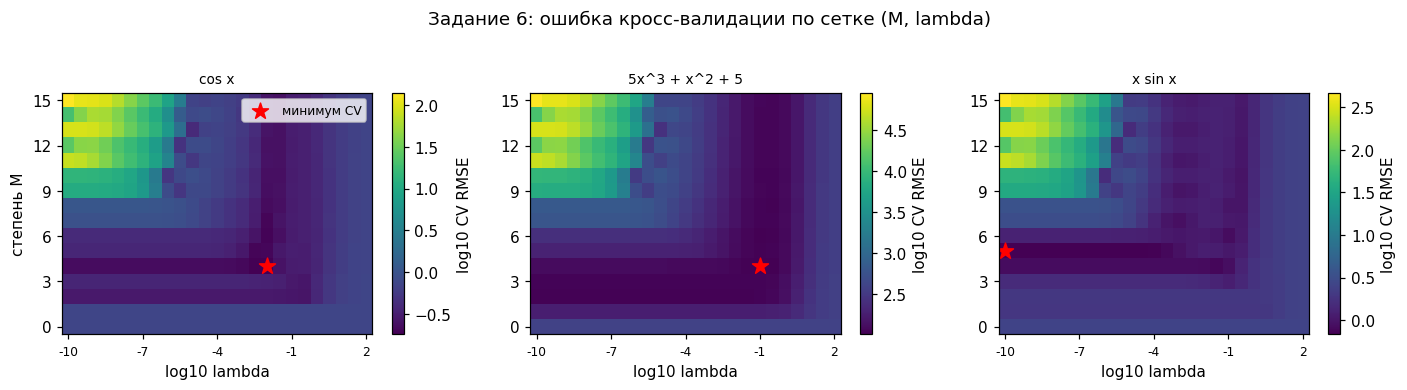

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, name in zip(axes, FUNCS):
    s = cvres[(cvres.func == name) & (cvres.noise == 'нормальный') & (cvres.lam > 0)]
    piv = s.pivot_table(index='M', columns='lam', values='cv')
    im = ax.imshow(np.log10(piv.values), aspect='auto', origin='lower', cmap='viridis')
    # номер минимума в развёрнутой таблице переводится в строку и столбец
    j, i = np.unravel_index(np.argmin(piv.values), piv.shape)
    ax.scatter([i], [j], color='red', marker='*', s=120, label='минимум CV')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('log10 lambda')
    ax.set_xticks(range(0, len(piv.columns), 6))
    ax.set_xticklabels([f'{np.log10(v):.0f}' for v in piv.columns[::6]], fontsize=8)
    ax.set_yticks(range(0, 16, 3))
    plt.colorbar(im, ax=ax, label='log10 CV RMSE')
axes[0].set_ylabel('степень M')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Задание 6: ошибка кросс-валидации по сетке (M, lambda)', y=1.03)
plt.tight_layout()
plt.show()

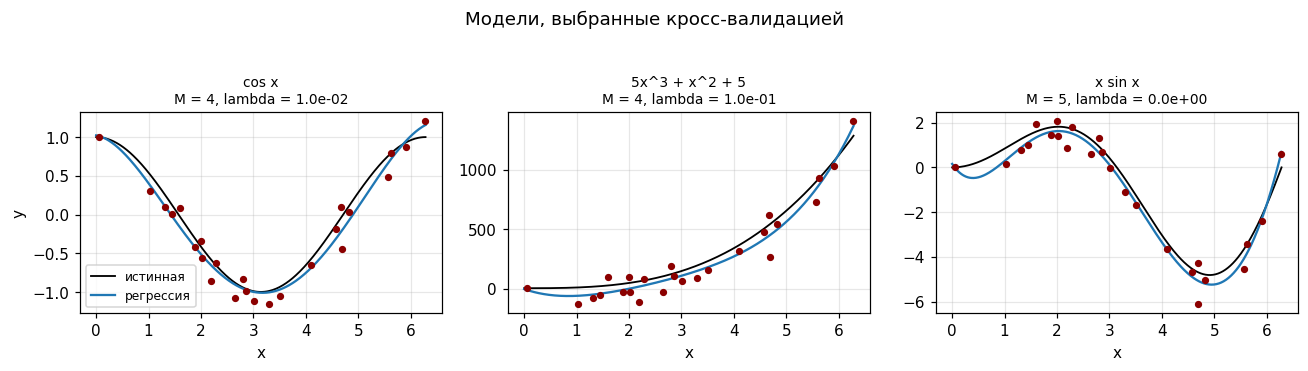

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(A_INT, B_INT, 400)
for ax, name in zip(axes, FUNCS):
    f = FUNCS[name]
    row = best_cv[(best_cv.func == name) & (best_cv.noise == 'нормальный')].iloc[0]
    rng = np.random.default_rng(20260905)
    x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE[name], rng)
    w = fit(x_tr, y_tr, int(row.M), float(row.lam))
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_title(f'{name}\nM = {int(row.M)}, lambda = {row.lam:.1e}', fontsize=9)
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
fig.suptitle('Модели, выбранные кросс-валидацией', y=1.04)
plt.tight_layout()
plt.show()